In [103]:
import pandas as pd
import matplotlib.pyplot as plt

day_1 = pd.read_csv('../../round_data/prices_round_5_day_2.csv', delimiter=';')
day_2 = pd.read_csv('../../round_data/prices_round_5_day_3.csv', delimiter=';')
day_3 = pd.read_csv('../../round_data/prices_round_5_day_4.csv', delimiter=';')
day_2.timestamp += 1e6
day_3.timestamp += 2e6
prices = pd.concat([day_1,day_2,day_3])
product_names = list(prices['product'].unique())
price_dfs = {name:prices[prices['product']==name].reset_index(drop=True)for name in product_names}

day_1 = pd.read_csv('../../round_data/trades_round_5_day_2.csv', delimiter=';')
day_2 = pd.read_csv('../../round_data/trades_round_5_day_3.csv', delimiter=';')
day_3 = pd.read_csv('../../round_data/trades_round_5_day_4.csv', delimiter=';')
day_2.timestamp += 1e6
day_3.timestamp += 2e6
trades = pd.concat([day_1,day_2,day_3])

trades_dfs = {name:trades[trades['symbol']==name].reset_index(drop=True)for name in product_names}

In [13]:
class Product:
    SQUID = "SQUID_INK"
    KELP = "KELP"
    RESIN = "RAINFOREST_RESIN"
    PICNIC_1 = "PICNIC_BASKET1"
    PICNIC_2 = "PICNIC_BASKET2"
    CROISSANTS = "CROISSANTS"
    JAMS = "JAMS"
    DJEMBES = "DJEMBES"
    SYNTHETIC_1 = "SYNTHETIC_1"
    SYNTHETIC_2 = "SYNTHETIC_2"
    ROCK = "VOLCANIC_ROCK"
    VOUCHER_9500 = "VOLCANIC_ROCK_VOUCHER_9500"
    VOUCHER_9750 = 'VOLCANIC_ROCK_VOUCHER_9750'
    VOUCHER_10000 = 'VOLCANIC_ROCK_VOUCHER_10000'
    VOUCHER_10250 = 'VOLCANIC_ROCK_VOUCHER_10250'
    VOUCHER_10500 = 'VOLCANIC_ROCK_VOUCHER_10500'
    
    
BASKET_WEIGHTS = {
    Product.PICNIC_1: {
        Product.CROISSANTS: 6,
        Product.DJEMBES: 1,
        Product.JAMS: 3,
        },
    Product.PICNIC_2: {
        Product.CROISSANTS: 4,
        Product.JAMS: 2,
    }
}

In [43]:
picnic_1_mid = price_dfs[Product.PICNIC_1].mid_price
picnic_2_mid = price_dfs[Product.PICNIC_2].mid_price
croissants_mid = price_dfs[Product.CROISSANTS].mid_price
jams_mid = price_dfs[Product.JAMS].mid_price
djembes_mid = price_dfs[Product.DJEMBES].mid_price

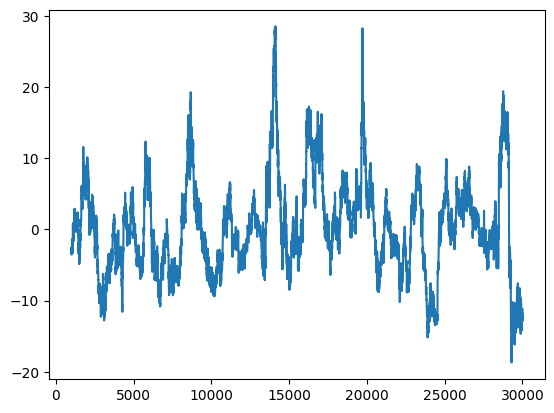

In [127]:
# plt.plot(croissants_mid)
# plt.plot(croissants_mid.rolling(1000).mean())
# croissants_mid.rolling(1000).mean().iloc[-1]
plt.plot(croissants_mid-croissants_mid.rolling(1000).mean())

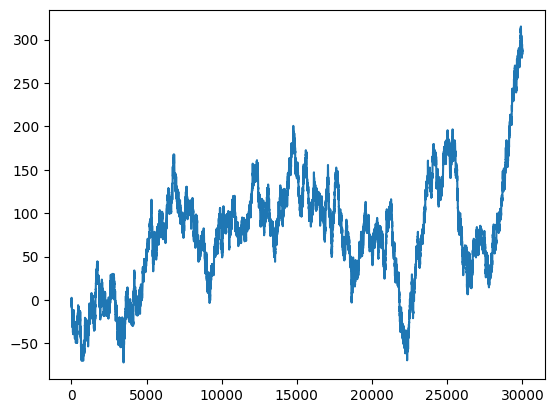

In [ ]:
# plt.plot(picnic_1_mid)
spread = picnic_2_mid - (croissants_mid*4 + jams_mid*2)
plt.plot(spread)

In [137]:
import numpy as np
def hurst_exponent(ts: pd.Series, max_lag=100):
    lags = range(2, max_lag)
    tau = [np.std(ts.diff(lag).dropna()) for lag in lags]
    hurst = np.polyfit(np.log(lags), np.log(tau), 1)[0]
    return hurst

100%|██████████| 29800/29800 [10:28<00:00, 47.41it/s]


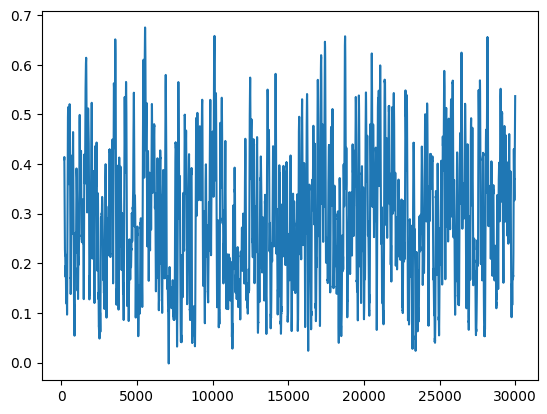

In [148]:
hursts = [np.nan]*200
from tqdm import tqdm

for i in tqdm(range(len(spread)-200)):
    hursts.append(hurst_exponent(spread.iloc[i:i+200]))

plt.plot(hursts)

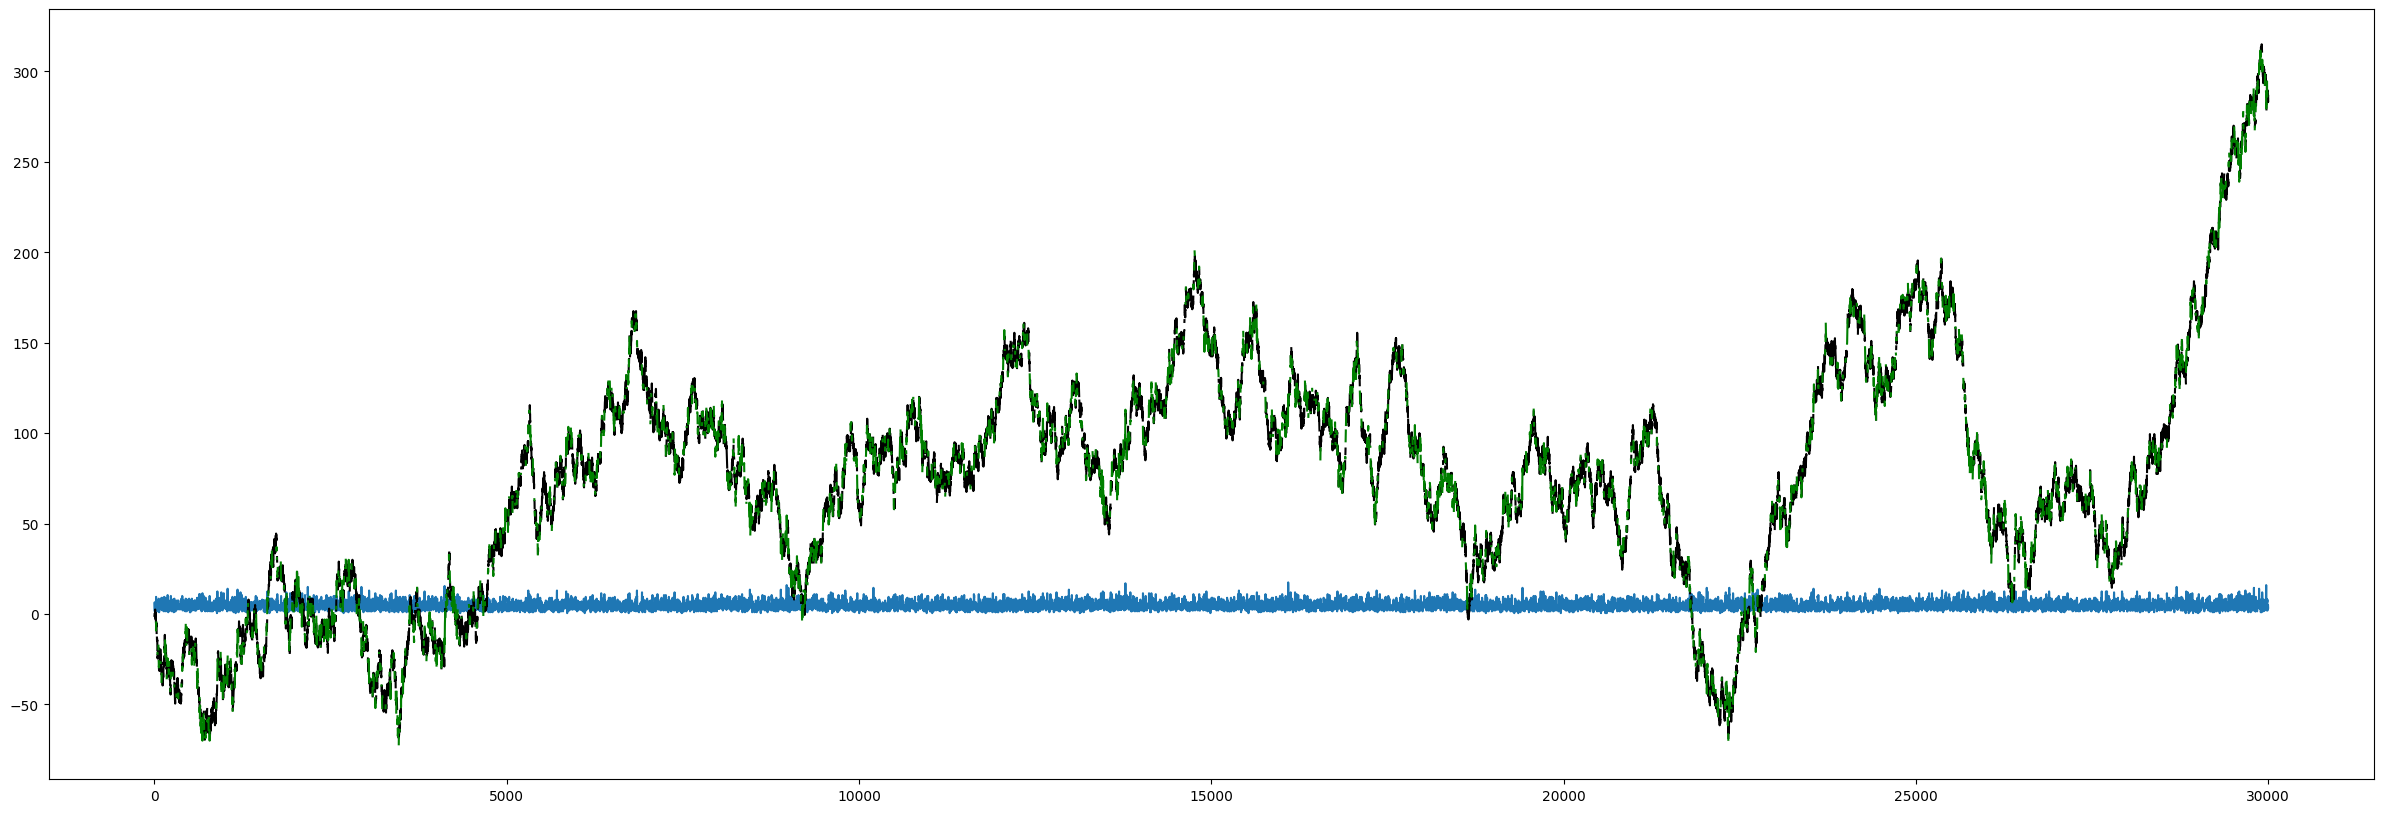

In [188]:
regime_indicator = (spread.rolling(5).max()-spread.rolling(5).min())
# regime_indicator = (spread.rolling(30).max()-spread.rolling(30).min())
fig,ax = plt.subplots(figsize=(30,10))
plt.plot(regime_indicator)
plt.plot((spread*(regime_indicator<=6)).replace(0,np.nan),color='k')
plt.plot((spread*(regime_indicator>6)).replace(0,np.nan),color='green')


0 0


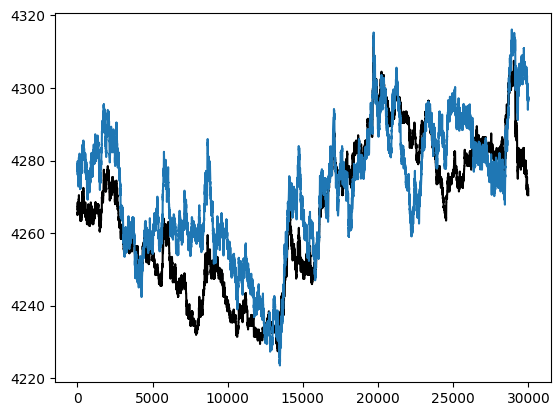

In [76]:
croissants_from_picnic1 = ((picnic_1_mid - jams_mid*3 - djembes_mid)/6)
croissants_from_picnic2 = ((picnic_2_mid - jams_mid*2)/4)
from scipy.stats import linregress
import numpy as np
x = croissants_mid.values[1:]
best_r = 0
best_n = 0
# for n1 in np.linspace(0,1,100):
#     for n2 in np.linspace(0,1,100):
#         for n3 in np.linspace(0,1,100):
#             if n1+n2+n3 == 1:
#                 y = (croissants_from_picnic1[:-1]*n1+croissants_from_picnic2[:-1]*n2+croissants_mid.values[:-1]*n3)
#                 r = linregress(x,y)[2]
#                 if best_r<r:
#                     best_r = r
#                     best_n = (n1,n2,n3)
print(best_r, best_n)
# n1,n2,n3 = best_n
n1 = 0.5
n2 = 0.5
n3 = 0
plt.plot(croissants_mid[1:], color='k')
plt.plot((croissants_from_picnic1[:-1]*n1+croissants_from_picnic2[:-1]*n2+croissants_mid[:-1]*n3))

4272.225

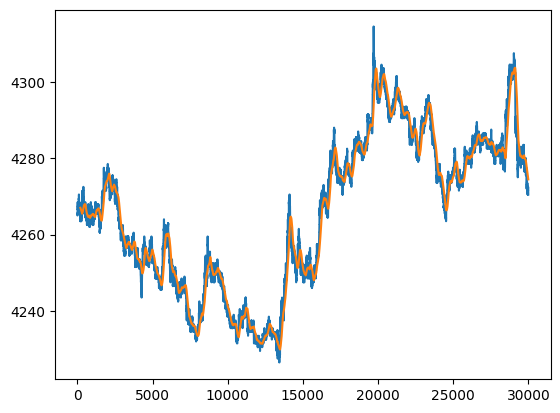

In [81]:
plt.plot(croissants_mid)
plt.plot(croissants_mid.rolling(200).mean())
# plt.plot(croissants_mid-croissants_mid.rolling(100).mean())

croissants_mid.rolling(100).mean().iloc[-1]

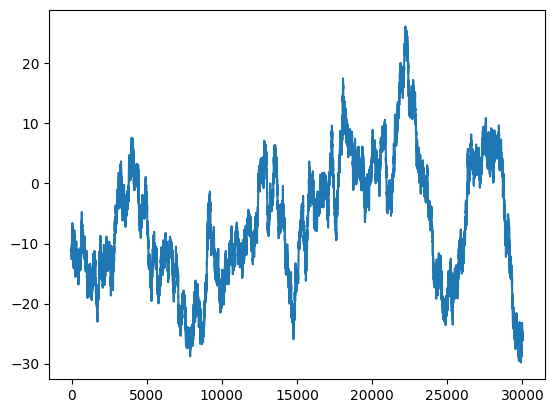

In [72]:
croissants_estimate = (croissants_from_picnic1+croissants_from_picnic2)/2
plt.plot(croissants_mid-croissants_estimate)

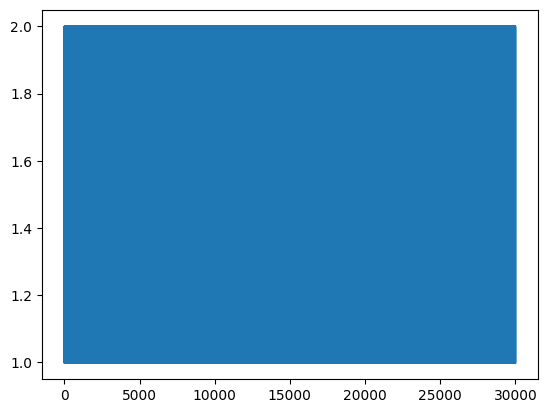

In [73]:
plt.plot(price_dfs[Product.CROISSANTS].ask_price_1-price_dfs[Product.CROISSANTS].bid_price_1)

In [71]:
last_returns = croissants_mid.pct_change().dropna()
estimate_croissants = (croissants_from_picnic1+croissants_from_picnic2)/2
spread = (croissants_mid-estimate_croissants)
from scipy.stats import linregress
import numpy as np
from tqdm import tqdm
x = croissants_mid.values[3:]
best_r = 0
best_n = 0
for fact in tqdm(np.linspace(-1,1,200)):
    for fact2 in np.linspace(-1,1,1000):
        y = (croissants_mid[1:-2]*(1+last_returns.iloc[:-2]*fact)+fact2*spread.iloc[1:-2]).values
        r = linregress(x,y)[2]
        if best_r<r:
            best_r = r
            best_n = (fact,fact2)
print(best_n, best_r)

100%|██████████| 200/200 [01:50<00:00,  1.81it/s]

(-0.09547738693467334, 0.0010010010010010895) 0.9996163995844669


0.9997302267679021 (0.0, 0.0, 1.0)


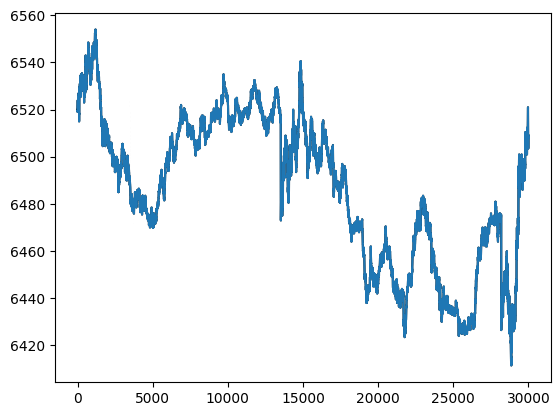

In [46]:
jams_from_picnic1 = (picnic_1_mid - croissants_mid*6 - djembes_mid)/3
jams_from_picnic2 = (picnic_2_mid - croissants_mid*4)/2
from scipy.stats import linregress
import numpy as np
x = jams_mid.values[1:]
best_r = 0
best_n = 0
for n1 in np.linspace(0,1,100):
    for n2 in np.linspace(0,1,100):
        for n3 in np.linspace(0,1,100):
            if n1+n2+n3 == 1:
                y = (jams_from_picnic1[:-1]*n1+jams_from_picnic2[:-1]*n2+jams_mid.values[:-1]*n3)
                r = linregress(x,y)[2]
                if best_r<r:
                    best_r = r
                    best_n = (n1,n2,n3)
print(best_r, best_n)
n1,n2,n3 = best_n
plt.plot(jams_mid[1:], color='k')
plt.plot((jams_from_picnic1[:-1]*n1+jams_from_picnic2[:-1]*n2+jams_mid[:-1]*n3))
# jams_estimate = (jams_from_picnic1*best_n+jams_from_picnic2*(1-best_n))

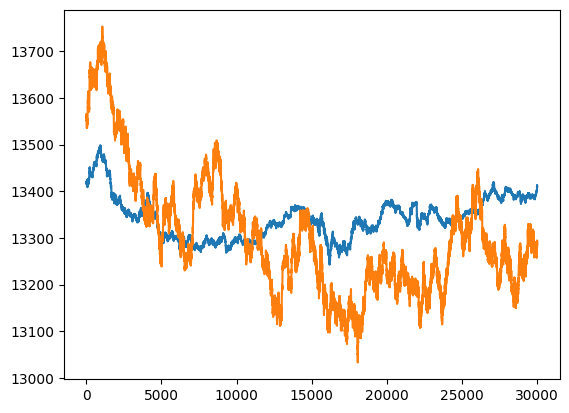

In [38]:
djembes_from_picnic_1 = (picnic_1_mid - croissants_mid*6 - jams_mid*3)
plt.plot(djembes_mid)
plt.plot(djembes_from_picnic_1)

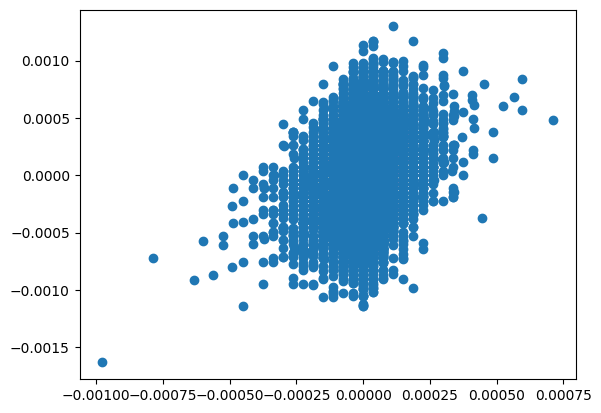

In [112]:
plt.scatter(djembes_mid.pct_change(),djembes_from_picnic_1.pct_change())

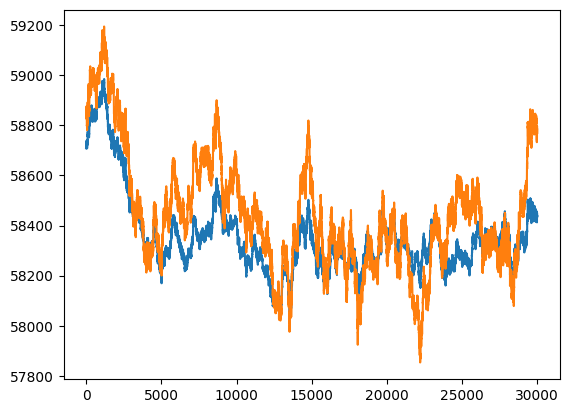

In [40]:
djembes_from_picnic_1 = (picnic_1_mid - croissants_mid*6 - jams_mid*3)
picnic_1_estimate = croissants_estimate * 6 + djembes_from_picnic_1 + jams_estimate*3
plt.plot(picnic_1_mid)
plt.plot(picnic_1_estimate)